# Ch.00 — Overview: The Implied Order Book (GEX Ed.)

**Paper:** SqueezeMetrics / GEX Ed., *The Implied Order Book* (6 July 2020)  
**NOTES:** [`NOTES.md`](NOTES.md) · **SoT:** [`../../CHAPTER_INDEX.md`](../../CHAPTER_INDEX.md)

Core claim: options dealers' **gamma / vanna** invent an *implied* limit order book that can absorb or amplify spot moves. Desk maps SPX pit GEX → **Deribit ETH options IV + PROXY_trade_flow_DDOI** (warehouse OI is **futures-only**) on certified `panel_gex_options` **n=9**. Visible TOB co-move = context only — **Kill** TOB-cross α. `trade_synth` **QUARANTINED**.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / "research" / "books" / "squeeze_metrics"
OUT = BOOK / "out"
SCRIPTS = BOOK / "scripts"
ROOT = BOOK.parents[2]
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(ROOT))
from _nb_common import (
    load_json, gex_day_table, safe_corr, partial_corr_vs_rv, lead_lag_day, SIGNAL_BOARD,
)
from certified_panel import load_certified, primary_days, spot_l2_days, gex_panel_days, DDOI_LABEL, GEX_PROXY_LABEL
from research.lib import squeeze  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_pngs(fig_dir: Path, pattern="*.png"):
    if not fig_dir.is_dir():
        print("no figs dir", fig_dir)
        return
    for p in sorted(fig_dir.glob(pattern)):
        display(Markdown(f"**{p.name}** — `{p.relative_to(BOOK)}`"))
        display(Image(filename=str(p)))

def print_board(rows=None):
    rows = rows or SIGNAL_BOARD
    print(f"{'id':34s} {'gate':6s} note")
    print("-" * 88)
    for i, g, n in rows:
        print(f"{i:34s} {g:6s} {n}")

CERT = load_certified()
PRIMARY = primary_days(CERT)
SPOT = spot_l2_days(CERT)
GEX_DAYS = gex_panel_days(CERT)
print("BOOK", BOOK)
print("certified primary n=", len(PRIMARY), PRIMARY)
print("panel_gex_options n=", len(GEX_DAYS), GEX_DAYS)
print("spot_l2 subpanel n=", len(SPOT), SPOT)
print("DDOI label", DDOI_LABEL, "| GEX proxy", GEX_PROXY_LABEL)
print("trade_synth QUARANTINED — never primary; warehouse OI futures-only unused")


BOOK /home/dev/srv/ares-microstructure/research/books/squeeze_metrics
certified primary n= 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
panel_gex_options n= 11 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-19', '2026-09-25', '2026-09-26', '2026-09-27', '2026-09-29', '2026-10-01']
spot_l2 subpanel n= 5 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-09-29', '2026-10-01']
DDOI label PROXY_trade_flow_DDOI | GEX proxy BS_GEX_trade_flow_DDOI
trade_synth QUARANTINED — never primary; warehouse OI futures-only unused


## Crypto map vs paper objects

| Paper | Desk |
|-------|------|
| SPX options chain / pit dealers | Deribit ETH options `implied_vol` + trade tape |
| DDOI (trade dir + ΔOI) | **PROXY_trade_flow_DDOI** (aggressor × qty); futures OI unused |
| GEX = Σ DDOI · γ · $ | `squeeze.chain_exposures` / `aggregate_gex` — `BS_GEX_trade_flow_DDOI` |
| VEX = Σ DDOI · ∂δ/∂σ · $ | Same with BS vanna |
| GEX+ / abundance maps | GEX+VEX; scarce flag vs HL range/RV |
| Visible LOB “bluff” | HL/Deribit TOB + Kraken `spot_l2` — **Kill** as α |
| RTH session | **UTC-day** panels; 24/7 tape |


In [2]:

gex = load_json(OUT / "gex_implied_book" / "summary.json")
ddoi = load_json(OUT / "ddoi_positions" / "summary.json")
vex = load_json(OUT / "vex_vanna" / "summary.json")
sq = load_json(OUT / "squeeze_regimes" / "summary.json")
comp = load_json(OUT / "panel_completeness" / "certified_panels.json")
print("GEX n_ok", None if not gex else gex.get("n_ok"), "corr_gex_hl_rv", None if not gex else gex.get("corr_gex_hl_rv"))
print("DDOI n_ok", None if not ddoi else ddoi.get("n_ok"), "label", None if not ddoi else ddoi.get("label"))
print("VEX n_ok", None if not vex else vex.get("n_ok"), "corr_vex_range", None if not vex else vex.get("corr_vex_hl_range"))
print("squeeze n_ok", None if not sq else sq.get("n_ok"), "n_scarce", None if not sq else sq.get("n_scarce"))
print("primary panel", (comp or {}).get("primary", {}).get("panel"), "n", (comp or {}).get("primary", {}).get("n"))
print("blockers", (comp or {}).get("blockers"))


GEX n_ok 9 corr_gex_hl_rv -0.2162754128722743
DDOI n_ok 9 label PROXY_trade_flow_DDOI
VEX n_ok 9 corr_vex_range 0.4235963147604336
squeeze n_ok 9 n_scarce 4
primary panel panel_gex_options n 9
blockers {'option_oi': 'Deribit warehouse open_interest is FUTURES-ONLY. Option DDOI uses PROXY_trade_flow_DDOI (or live API OI snapshot).', 'clickhouse_mcp': 'BANNED — not used'}


## Pass-1 scoreboard snapshot


,day,ok,spot,gex,vex,gex_plus,squeeze_intensity,scarce,dealer_sign,ddoi_mode,opt_iv_n,opt_trade_n,hl_tob_n,hl_rv,hl_range,db_rv,db_range,kraken
0,2026-09-14,True,2511.345,86891.2836,34545.6417,121436.9253,0.0,False,stabilizing_long_dealer_gamma,PROXY_trade_flow_DDOI,749,2411,123,0.0021,0.0339,0.0010,0.0225,absent_2venue
1,2026-09-15,True,2475.410,-126980.8612,161949.6828,34968.8216,1.0,False,destabilizing_short_dealer_gamma,PROXY_trade_flow_DDOI,673,4810,126,0.0029,0.0455,0.0009,0.0396,absent_2venue
2,2026-09-16,True,2402.230,17436.9415,42467.6671,59904.6087,0.0,False,stabilizing_long_dealer_gamma,PROXY_trade_flow_DDOI,629,1504,124,0.0026,0.0216,0.0005,0.0084,absent_2venue
3,2026-09-17,True,2450.655,5832.2306,100798.0991,106630.3296,0.0,False,stabilizing_long_dealer_gamma,PROXY_trade_flow_DDOI,581,1657,125,0.0021,0.0268,0.0005,0.0155,absent_2venue
4,2026-09-18,True,2461.820,-1491.2236,-14101.2149,-15592.4384,2.0,True,destabilizing_short_dealer_gamma,PROXY_trade_flow_DDOI,559,2283,127,0.0023,0.0555,0.0006,0.0222,absent_2venue
5,2026-09-25,True,2680.250,-7410.1917,4183.9703,-3226.2214,1.0,True,destabilizing_short_dealer_gamma,PROXY_trade_flow_DDOI,500,1764,124,0.0018,0.0193,0.0005,0.0097,spot_l2
6,2026-09-26,True,2689.525,-308.6851,-79.4097,-388.0948,2.0,True,destabilizing_short_dealer_gamma,PROXY_trade_flow_DDOI,422,215,125,0.0007,0.0096,0.0003,0.0053,spot_l2
7,2026-09-27,True,2691.590,2462.3547,7553.6992,10016.0540,0.0,False,stabilizing_long_dealer_gamma,PROXY_trade_flow_DDOI,420,207,125,0.0010,0.0175,0.0004,0.0119,spot_l2
8,2026-10-01,True,2695.640,-51646.2271,-83296.6944,-134942.9215,2.0,True,destabilizing_short_dealer_gamma,PROXY_trade_flow_DDOI,419,440,126,0.0014,0.0131,0.0007,0.0149,spot_l2


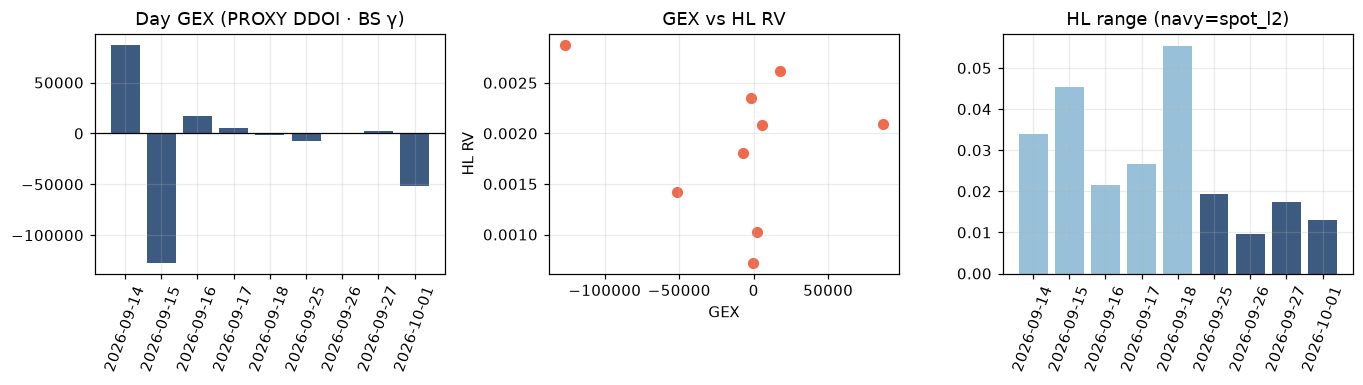

ddoi modes: {'PROXY_trade_flow_DDOI': 9}
kraken modes: {'absent_2venue': 5, 'spot_l2': 4}


In [3]:

rows = (gex or {}).get("rows") or load_json(OUT / "gex_implied_book" / "panel_rows.json") or []
tbl = gex_day_table(rows, CERT)
display(tbl.round(4) if len(tbl) else tbl)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
ok = tbl[tbl["ok"] == True] if len(tbl) else tbl
if len(ok):
    axes[0].bar(ok["day"], ok["gex"], color="#3d5a80")
    axes[0].tick_params(axis="x", rotation=70)
    axes[0].set_title("Day GEX (PROXY DDOI · BS γ)")
    axes[0].axhline(0, color="k", lw=0.8)
    axes[1].scatter(ok["gex"], ok["hl_rv"], c="#ee6c4d", s=40)
    axes[1].set_xlabel("GEX"); axes[1].set_ylabel("HL RV"); axes[1].set_title("GEX vs HL RV")
    colors = ["#3d5a80" if m == "spot_l2" else "#98c1d9" for m in ok["kraken"]]
    axes[2].bar(ok["day"], ok["hl_range"], color=colors)
    axes[2].tick_params(axis="x", rotation=70)
    axes[2].set_title("HL range (navy=spot_l2)")
else:
    for ax in axes:
        ax.text(0.5, 0.5, "run exp_gex_panel.py", ha="center", transform=ax.transAxes)
plt.tight_layout(); plt.show()
print("ddoi modes:", ok["ddoi_mode"].value_counts().to_dict() if len(ok) else {})
print("kraken modes:", ok["kraken"].value_counts().to_dict() if len(ok) else {})


## Reading order

1. `ddoi_positions` — PROXY_trade_flow_DDOI coverage  
2. `gex_implied_book` — GEX vs RV/range  
3. `vex_vanna` — VEX / GEX+  
4. `squeeze_regimes` — scarcity / stress–calm  
5. `robustness` — falsifier checklist  
6. `paper_shadow` — living monitor (`live_orders=false`)

Desk rollup: [`../../notebooks/desk_synthesis.ipynb`](../../notebooks/desk_synthesis.ipynb) · Info board: [`../../notebooks/info_stats_board.ipynb`](../../notebooks/info_stats_board.ipynb).


## Signal board


In [4]:

print_board()
print("\\n0 Promote · Hold monitors · Kill TOB-cross α · Kill trade_synth")


id                                 gate   note
----------------------------------------------------------------------------------------
risk.gex_exposure                  Hold   Σ PROXY_trade_flow_DDOI · BS-γ · panel_gex_options n=9 — monitor≠α
risk.vex_exposure                  Hold   Σ DDOI · BS-vanna vs HL range/RV — Hold
risk.squeeze_intensity             Hold   GEX+ scarcity / stress–calm — Hold
liq.implied_book_scarcity          Hold   Abundance / scarce labels from GEX+ — Hold
liq.gex_rv_link                    Hold   corr(GEX, HL RV)≈−0.22; day-block CI crosses 0 — research tile
risk.squeeze_falsifier_board       Hold   Pass-2b chrono / day-block / placebo / venue-drop / LOO — 0 Promote
info.gex_range_incremental         Hold   partial(range,GEX|RV)≈0 · ΔR²≈0 — vol-overlap honesty tile
info.squeeze_after_gex             Hold   ΔR²(squeeze|GEX) on range ~0 — research
info.vex_incremental               Hold   ΔR²(VEX|RV+GEX)~0 — research
info.gex_leadlag_map               Hold   